In [33]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
%matplotlib inline

In [34]:
df_test = pd.read_csv("dataset/teen_test_clean.csv")
df_test.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,1.490790,-0.513854,-1.077065,-1.729166,1.201832,1.283458,0.882057,-0.545846,-0.904702,0,1,0,3.68
1,-0.469701,0.963386,-0.731297,0.497713,1.374035,-1.195656,0.540753,-0.896825,0.149746,1,0,1,3.44
2,1.000667,-1.055508,-0.108917,-0.615726,1.201832,-1.195656,-1.165766,1.209050,-0.201737,0,1,0,3.05


In [35]:
df_train = pd.read_csv("dataset/teen_train_clean.csv")
df_train.head(3)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,target_academic_performance
0,0.020422,0.766421,1.135845,-0.476546,1.029629,-1.195656,1.564665,-1.598783,-0.553219,0,1,0,3.27
1,-0.469701,0.569455,0.720924,0.915253,0.513021,0.043901,1.564665,1.560029,-1.256185,0,1,0,2.84
2,-1.449946,-1.695645,0.444311,0.080173,-0.347993,1.283458,-0.141854,-0.194867,1.555678,1,0,1,2.55


In [36]:
y_test = df_test['target_academic_performance']
df_test = df_test.drop(columns=['target_academic_performance'])
X_test = df_test.copy()
y_test.head()

0    3.68
1    3.44
2    3.05
3    3.56
4    2.16
Name: target_academic_performance, dtype: float64

In [37]:
X_test.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,1.490790,-0.513854,-1.077065,-1.729166,1.201832,1.283458,0.882057,-0.545846,-0.904702,0,1,0
1,-0.469701,0.963386,-0.731297,0.497713,1.374035,-1.195656,0.540753,-0.896825,0.149746,1,0,1
2,1.000667,-1.055508,-0.108917,-0.615726,1.201832,-1.195656,-1.165766,1.209050,-0.201737,0,1,0
3,-1.449946,-1.055508,-0.662144,-1.589986,1.029629,0.043901,-0.483158,0.858071,0.501229,0,1,0
4,-1.449946,1.357317,-1.561139,-0.615726,-0.003588,1.283458,-0.483158,-0.194867,-1.256185,1,0,0


In [38]:
y_train = df_train['target_academic_performance']
df_train = df_train.drop(columns=['target_academic_performance'])
X_train = df_train.copy()
y_train.head()

0    3.27
1    2.84
2    2.55
3    2.54
4    3.81
Name: target_academic_performance, dtype: float64

In [39]:
X_train.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok
0,0.020422,0.766421,1.135845,-0.476546,1.029629,-1.195656,1.564665,-1.598783,-0.553219,0,1,0
1,-0.469701,0.569455,0.720924,0.915253,0.513021,0.043901,1.564665,1.560029,-1.256185,0,1,0
2,-1.449946,-1.695645,0.444311,0.080173,-0.347993,1.283458,-0.141854,-0.194867,1.555678,1,0,1
3,0.020422,0.372490,-1.491985,-0.337366,-1.209007,1.283458,0.540753,0.507092,1.555678,0,0,1
4,-0.959824,0.914145,-0.316377,-0.894086,-0.175790,0.043901,0.882057,-1.247804,-0.904702,0,1,0


In [ ]:
BATCH_SIZE = 32

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train.values, test_size=0.15
)

train_pipeline = tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final))
train_pipeline = train_pipeline.shuffle(buffer_size=len(X_train_final)).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test.to_numpy(), y_test.to_numpy())).batch(BATCH_SIZE)

In [ ]:
class TestEvaluationCallback(tf.keras.callbacks.Callback):
    def __init__(self, test_data):
        super().__init__()
        self.test_data = test_data
        self.test_losses = []

    def on_epoch_end(self, epoch, logs=None):
        results = self.model.evaluate(self.test_data, verbose=0)
        self.test_losses.append(results[0])
        print(f" - test_loss: {results[0]:.4f}")

test_eval_callback = TestEvaluationCallback(test_dataset)

In [ ]:
input_shape_dim = X_train.shape[1]
model = Sequential([
   Input(shape=(input_shape_dim,)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',             
    loss='mse',                   
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]       
)

In [ ]:
test_eval_callback = TestEvaluationCallback(test_dataset)
history = model.fit(
    train_pipeline,
    epochs=600, 
    validation_data=val_dataset,
    callbacks=[test_eval_callback],
    verbose=1)

Epoch 1/600
 1/26 ━━━━━━━━━━━━━━━━━━━━ 19s 766ms/step - loss: 8.7368 - mae: 2.9225 - rmse: 2.9558 - test_loss: 0.4662
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.2945 - mae: 1.1882 - rmse: 1.5148 - val_loss: 0.4328 - val_mae: 0.5497 - val_rmse: 0.6579
Epoch 2/600
 1/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5192 - mae: 0.5850 - rmse: 0.7206 - test_loss: 0.4538
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4903 - mae: 0.5787 - rmse: 0.7002 - val_loss: 0.4172 - val_mae: 0.5451 - val_rmse: 0.6459
Epoch 3/600
 1/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4409 - mae: 0.5655 - rmse: 0.6640 - test_loss: 0.4625
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4631 - mae: 0.5539 - rmse: 0.6805 - val_loss: 0.4221 - val_mae: 0.5374 - val_rmse: 0.6497
Epoch 4/600
 1/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3307 - mae: 0.5010 - rmse: 0.5751 - test_loss: 0.4506
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4280 - mae: 0.5400 - rmse: 0.6542 - val_loss: 0.4082 - val_mae: 0.5463 

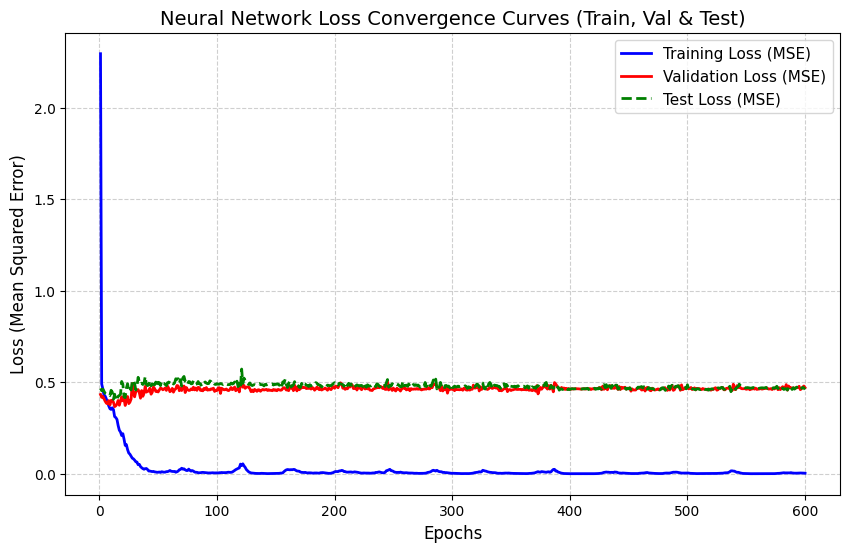

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
test_loss = test_eval_callback.test_losses
epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_loss, 'b-', label='Training Loss (MSE)', linewidth=2)
plt.plot(epochs_range, val_loss, 'r-', label='Validation Loss (MSE)', linewidth=2)
plt.plot(epochs_range, test_loss, 'g--', label='Test Loss (MSE)', linewidth=2)

plt.title('Neural Network Loss Convergence Curves (Train, Val & Test)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()